# Proyecto Primer Parcial

## Automatización del Análisis y Visualización de Datos Climáticos

**Asignatura:** Bases de Programación

**Estudiantes:** José Maldonado y Joao Córdova

**Docente:** Freddy Carrión M.

**Fecha:** 29 Junio 2026

# 2. Introducción

El análisis de datos climáticos permite comprender el comportamiento de variables ambientales como la temperatura, la humedad, la precipitación y la velocidad del viento. El procesamiento de grandes volúmenes de información requiere herramientas que faciliten la organización, limpieza, análisis y visualización de los datos de manera eficiente.

En este proyecto se emplea el lenguaje de programación **Python** y la biblioteca **Pandas** para automatizar el procesamiento de un conjunto de datos climáticos correspondiente a varias ciudades de Estados Unidos. Además, se utilizan funciones y estructuras de programación que permiten desarrollar un análisis reproducible, obteniendo estadísticas descriptivas, realizando operaciones de manipulación de datos y generando visualizaciones que facilitan la interpretación de los resultados.


# 3. Objetivo

Desarrollar un programa en Python que automatice el proceso de carga, limpieza, análisis y visualización de un conjunto de datos climáticos, utilizando la biblioteca Pandas y funciones para facilitar la manipulación de la información, obtener estadísticas descriptivas y generar representaciones gráficas que permitan interpretar los datos de manera eficiente y reproducible.


# 4. Importación de librerías

En esta sección se importan las librerías necesarias para el desarrollo del proyecto. Estas herramientas permiten realizar la carga, manipulación, análisis y visualización de los datos climáticos. Cada biblioteca cumple una función específica dentro del procesamiento de la información y será utilizada en las diferentes etapas del análisis.


In [2]:

# Importación de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 5. Carga de datos

En esta sección se carga el conjunto de datos climáticos utilizando la biblioteca **Pandas**. El archivo se almacena en un **DataFrame**, una estructura de datos tabular que facilita la manipulación, el análisis y la visualización de la información. Posteriormente, se verifica que la carga se haya realizado correctamente mediante la inspección de las primeras filas y la estructura general del conjunto de datos.


In [3]:

# Carga del conjunto de datos

# Nombre del archivo
archivo = "Weather_Data-1.csv"

# Cargar el archivo CSV en un DataFrame
datos = pd.read_csv(archivo)

# Mostrar las primeras filas
datos.head()

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,1/14/2024 21:12,10.683001,41.195754,4.020119,8.233540
1,San Diego,5/17/2024 15:22,8.734140,58.319107,9.111623,27.715161
2,San Diego,5/11/2024 9:30,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2/26/2024 17:32,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,4/29/2024 13:23,39.808213,72.899908,9.598282,29.898622


# 6. Limpieza de datos

La limpieza de datos es una etapa fundamental en cualquier proceso de análisis, ya que permite identificar y corregir posibles inconsistencias que puedan afectar los resultados. En esta sección se verifica la existencia de valores duplicados y se comprueba que cada variable tenga el tipo de dato adecuado para su procesamiento. Estas tareas se implementan mediante funciones con el fin de organizar el código y facilitar su reutilización.


In [4]:

# Información general del conjunto de datos

datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Location          1000000 non-null  str    
 1   Date_Time         1000000 non-null  str    
 2   Temperature_C     1000000 non-null  float64
 3   Humidity_pct      1000000 non-null  float64
 4   Precipitation_mm  1000000 non-null  float64
 5   Wind_Speed_kmh    1000000 non-null  float64
dtypes: float64(4), str(2)
memory usage: 45.8 MB


In [5]:

# Verificación de registros duplicados

duplicados = datos.duplicated().sum()

print(f"Número de registros duplicados: {duplicados}")

Número de registros duplicados: 0


In [6]:

# Función para convertir la columna Date_Time a tipo datetime

def convertir_fecha(df):
    """
    Convierte la columna Date_Time al tipo datetime.
    
    Parámetros:
        df (DataFrame): Conjunto de datos.
        
    Retorna:
        DataFrame: DataFrame con la columna Date_Time convertida.
    """
    
    df["Date_Time"] = pd.to_datetime(df["Date_Time"])

    return df

In [7]:
# Aplicar la función

datos = convertir_fecha(datos)

In [8]:
# Verificar el nuevo tipo de dato

datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   Location          1000000 non-null  str           
 1   Date_Time         1000000 non-null  datetime64[us]
 2   Temperature_C     1000000 non-null  float64       
 3   Humidity_pct      1000000 non-null  float64       
 4   Precipitation_mm  1000000 non-null  float64       
 5   Wind_Speed_kmh    1000000 non-null  float64       
dtypes: datetime64[us](1), float64(4), str(1)
memory usage: 45.8 MB


# 7. Resumen estadístico

El resumen estadístico permite obtener una visión general del comportamiento de las variables numéricas del conjunto de datos. Mediante medidas descriptivas como la media, la desviación estándar, los valores mínimos y máximos, así como los cuartiles, es posible identificar la distribución de los datos y detectar posibles valores atípicos antes de realizar análisis más específicos.


In [9]:


# Función para generar el resumen estadístico

def resumen_estadistico(df):
    """
    Genera un resumen estadístico de las variables numéricas.

    Parámetros:
        df (DataFrame): Conjunto de datos.

    Retorna:
        DataFrame: Resumen estadístico de las variables numéricas.
    """

    return df.describe(include=[np.number])

In [10]:
# Aplicar la función

estadisticas = resumen_estadistico(datos)

estadisticas

,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,14.779705,60.021830,5.109639,14.997598
std,14.482558,17.324022,2.947997,8.663556
min,-19.969311,30.000009,0.000009,0.000051
25%,2.269631,45.008500,2.580694,7.490101
50%,14.778002,60.018708,5.109917,14.993777
75%,27.270489,75.043818,7.613750,22.514110
max,39.999801,89.999977,14.971583,29.999973


## Interpretación del resumen estadístico

El conjunto de datos contiene **1 000 000 de registros** para cada una de las variables climáticas analizadas, lo que garantiza una muestra amplia para realizar el análisis.

La temperatura promedio registrada fue de aproximadamente **14.78 °C**, con valores comprendidos entre **−19.97 °C** y **40.00 °C**, lo que evidencia una amplia variabilidad climática entre las diferentes ciudades incluidas en el estudio.

La humedad relativa presentó un promedio cercano al **60 %**, con valores mínimos de **30 %** y máximos cercanos al **90 %**, indicando condiciones atmosféricas diversas.

La precipitación promedio fue de aproximadamente **5.11 mm**, mientras que la velocidad promedio del viento fue de **15.00 km/h**, alcanzando valores máximos cercanos a **30 km/h**.

En general, las estadísticas descriptivas permiten comprender el comportamiento de las variables climáticas y constituyen la base para el análisis exploratorio de datos que se desarrollará en las siguientes secciones.


# 8. Análisis Exploratorio de Datos (EDA)

## 8.1 Introducción

El análisis exploratorio de datos (EDA) es una etapa fundamental del proceso de análisis, ya que permite comprender el comportamiento de las variables mediante estadísticas descriptivas y la identificación de patrones relevantes. En esta sección se implementan funciones para calcular medidas estadísticas y se realizan análisis específicos del conjunto de datos con el propósito de responder preguntas relacionadas con las condiciones climáticas registradas.


## 8.2 Estadísticas descriptivas

En esta subsección se implementa una función que calcula las principales medidas de tendencia central y dispersión para las variables numéricas del conjunto de datos. En particular, se obtienen la **media**, la **mediana** y la **desviación estándar**, las cuales permiten describir el comportamiento general de la temperatura, la humedad, la precipitación y la velocidad del viento. Estas medidas constituyen la base para comprender la distribución de los datos antes de realizar análisis más específicos.


In [11]:

# Función para calcular estadísticas descriptivas

def calcular_estadisticas(df):
    """
    Calcula la media, mediana y desviación estándar de las variables numéricas.

    Parámetros:
        df (DataFrame): Conjunto de datos.

    Retorna:
        DataFrame: Tabla con las estadísticas descriptivas.
    """

    estadisticas = pd.DataFrame({
        "Media": df.mean(numeric_only=True),
        "Mediana": df.median(numeric_only=True),
        "Desviación Estándar": df.std(numeric_only=True)
    })

    return estadisticas

In [12]:
# Aplicar la función

estadisticas_eda = calcular_estadisticas(datos)

estadisticas_eda

,Media,Mediana,Desviación Estándar
Temperature_C,14.779705,14.778002,14.482558
Humidity_pct,60.021830,60.018708,17.324022
Precipitation_mm,5.109639,5.109917,2.947997
Wind_Speed_kmh,14.997598,14.993777,8.663556


### Interpretación de las estadísticas descriptivas

La temperatura presentó una **media de 14.78 °C** y una **mediana de 14.78 °C**, lo que indica una distribución aproximadamente simétrica de los datos. Además, la desviación estándar de **14.48 °C** evidencia una amplia variabilidad en los registros de temperatura.

La humedad relativa registró una **media de 60.02 %** y una **mediana de 60.02 %**, con una desviación estándar de **17.32 %**, lo que refleja una variación moderada entre las diferentes observaciones.

La precipitación mostró una **media de 5.11 mm** y una **mediana de 5.11 mm**, mientras que su desviación estándar fue de **2.95 mm**, indicando una dispersión relativamente baja respecto a otras variables climáticas.

Por su parte, la velocidad del viento presentó una **media de 15.00 km/h** y una **mediana de 14.99 km/h**, con una desviación estándar de **8.66 km/h**, lo que sugiere una variabilidad moderada en los registros analizados.

En general, la cercanía entre la media y la mediana en todas las variables indica que las distribuciones son relativamente equilibradas y que no existen diferencias importantes entre ambas medidas de tendencia central.


## 8.3 Análisis específicos

En esta subsección se realizan análisis específicos sobre el conjunto de datos con el objetivo de identificar patrones y responder preguntas relacionadas con las variables climáticas. Para ello, se utilizan funciones de agrupamiento y agregación de la biblioteca Pandas, permitiendo comparar el comportamiento de las diferentes ciudades y períodos de tiempo presentes en el conjunto de datos.


### 8.3.1 Temperatura promedio por ciudad

En este análisis se calcula la temperatura promedio registrada en cada ciudad mediante operaciones de agrupamiento. Esto permite identificar cuáles ciudades presentan las temperaturas medias más altas y comparar el comportamiento térmico entre las diferentes ubicaciones del conjunto de datos.


In [13]:

# Función para calcular la temperatura promedio por ciudad

def temperatura_promedio_ciudad(df):
    """
    Calcula la temperatura promedio de cada ciudad.

    Parámetros:
        df (DataFrame): Conjunto de datos.

    Retorna:
        DataFrame: Temperatura promedio por ciudad,
        ordenada de mayor a menor.
    """

    temperatura = (
        df.groupby("Location")["Temperature_C"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    return temperatura

In [14]:
# Aplicar la función

temp_ciudad = temperatura_promedio_ciudad(datos)

temp_ciudad

,Location,Temperature_C
0,Los Angeles,15.081063
1,Philadelphia,15.035892
2,San Antonio,15.027761
3,New York,15.013389
4,Chicago,15.009208
5,Dallas,15.009097
6,San Jose,14.956108
7,Houston,14.942985
8,San Diego,14.933539
9,Phoenix,12.792479


#### Interpretación

El análisis de la temperatura promedio por ciudad muestra que **Los Angeles** registró la temperatura media más alta, con aproximadamente **15.08 °C**. En contraste, **Phoenix** presentó la temperatura promedio más baja, con aproximadamente **12.79 °C**. En general, las diferencias entre las ciudades son relativamente pequeñas, lo que indica que las temperaturas medias del conjunto de datos presentan un comportamiento similar entre las distintas ubicaciones analizadas.


### 8.3.2 Precipitación promedio por ciudad

En este análisis se calcula la precipitación promedio registrada en cada ciudad utilizando operaciones de agrupamiento. El objetivo es identificar las ciudades con mayores y menores niveles promedio de precipitación y comparar su comportamiento climático.


In [15]:

# Función para calcular la precipitación promedio por ciudad

def precipitacion_promedio_ciudad(df):
    """
    Calcula la precipitación promedio de cada ciudad.

    Parámetros:
        df (DataFrame): Conjunto de datos.

    Retorna:
        DataFrame: Precipitación promedio por ciudad,
        ordenada de mayor a menor.
    """

    precipitacion = (
        df.groupby("Location")["Precipitation_mm"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    return precipitacion

In [16]:
# Aplicar la función

precipitacion_ciudad = precipitacion_promedio_ciudad(datos)

precipitacion_ciudad

,Location,Precipitation_mm
0,Phoenix,6.087485
1,Philadelphia,5.008561
2,San Antonio,5.008091
3,San Diego,5.006593
4,Los Angeles,5.004491
5,Chicago,5.003164
6,Houston,4.997757
7,Dallas,4.997508
8,New York,4.993057
9,San Jose,4.987398


#### Interpretación

El análisis de la precipitación promedio por ciudad muestra que **Phoenix** registró la mayor precipitación media, con aproximadamente **6.09 mm**, mientras que **San Jose** presentó la menor, con aproximadamente **4.99 mm**. En general, las diferencias entre las ciudades son relativamente pequeñas, lo que sugiere que la precipitación promedio mantiene un comportamiento similar entre las distintas ubicaciones consideradas en el conjunto de datos.


### 8.3.3 Velocidad promedio del viento por ciudad

En este análisis se calcula la velocidad promedio del viento registrada en cada ciudad mediante operaciones de agrupamiento. Este procedimiento permite identificar las ciudades con mayores y menores velocidades promedio del viento, facilitando la comparación de esta variable climática entre las diferentes ubicaciones del conjunto de datos.


In [17]:

# Función para calcular la velocidad promedio del viento por ciudad

def viento_promedio_ciudad(df):
    """
    Calcula la velocidad promedio del viento de cada ciudad.

    Parámetros:
        df (DataFrame): Conjunto de datos.

    Retorna:
        DataFrame: Velocidad promedio del viento por ciudad,
        ordenada de mayor a menor.
    """

    viento = (
        df.groupby("Location")["Wind_Speed_kmh"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    return viento

In [18]:
# Aplicar la función

viento_ciudad = viento_promedio_ciudad(datos)

viento_ciudad

,Location,Wind_Speed_kmh
0,San Diego,15.037633
1,Los Angeles,15.035120
2,Dallas,15.022001
3,Chicago,14.999501
4,Philadelphia,14.990663
5,Houston,14.989935
6,New York,14.989398
7,Phoenix,14.983904
8,San Jose,14.971369
9,San Antonio,14.956579


#### Interpretación

El análisis de la velocidad promedio del viento por ciudad muestra que **San Diego** registró la mayor velocidad media, con aproximadamente **15.04 km/h**, mientras que **San Antonio** presentó la menor, con aproximadamente **14.96 km/h**. Las diferencias entre las ciudades son muy pequeñas, lo que indica que la velocidad promedio del viento presenta un comportamiento bastante uniforme en el conjunto de datos analizado.


### 8.3.4 Mes con la temperatura promedio más alta

En este análisis se determina el mes que registró la mayor temperatura promedio. Para ello, se extrae el mes de la columna **Date_Time** y posteriormente se calcula la temperatura media de cada mes mediante operaciones de agrupamiento. Este procedimiento permite identificar la variación temporal de la temperatura durante el período analizado.


In [19]:

# Función para calcular la temperatura promedio por mes

def temperatura_promedio_mes(df):
    """
    Calcula la temperatura promedio de cada mes.

    Parámetros:
        df (DataFrame): Conjunto de datos.

    Retorna:
        DataFrame: Temperatura promedio por mes,
        ordenada de mayor a menor.
    """

    # Crear una copia para no modificar el DataFrame original
    df_mes = df.copy()

    # Extraer el mes
    df_mes["Mes"] = df_mes["Date_Time"].dt.month_name()

    temperatura_mes = (
        df_mes.groupby("Mes")["Temperature_C"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    return temperatura_mes

In [20]:
# Aplicar la función

temp_mes = temperatura_promedio_mes(datos)

temp_mes

,Mes,Temperature_C
0,May,15.042793
1,March,15.005691
2,April,15.001603
3,February,14.502081
4,January,14.446461


#### Interpretación

El análisis de la temperatura promedio por mes muestra que **mayo** registró la temperatura media más alta, con aproximadamente **15.04 °C**, seguido por **marzo** y **abril**, cuyos valores fueron muy similares. Por otro lado, **enero** presentó la temperatura promedio más baja, con aproximadamente **14.45 °C**. Estos resultados indican una ligera tendencia al incremento de la temperatura conforme avanza el período analizado.


## 8.4 Interpretación general

El análisis exploratorio permitió identificar el comportamiento general de las principales variables climáticas presentes en el conjunto de datos. Mediante el uso de funciones y operaciones de agrupamiento fue posible comparar las ciudades según su temperatura, precipitación y velocidad promedio del viento, así como analizar la variación temporal de la temperatura por mes.

Los resultados evidenciaron diferencias moderadas entre las ciudades para las variables analizadas, mientras que el análisis temporal mostró un ligero incremento de la temperatura promedio desde enero hasta mayo. En conjunto, este análisis proporciona una base sólida para continuar con la manipulación y transformación de los datos en las siguientes etapas del proyecto.


# 9. Manipulación de datos

## 9.1 Introducción

La manipulación de datos permite transformar y organizar la información para facilitar su análisis. En esta sección se aplican operaciones de agrupamiento, filtrado y creación de nuevas variables utilizando la biblioteca Pandas. Finalmente, el conjunto de datos modificado se exporta a un archivo de Excel para su almacenamiento y uso posterior.


## 9.2 Agrupamiento y agregación

Las operaciones de agrupamiento permiten resumir grandes volúmenes de información mediante funciones de agregación. En este análisis se calcula la temperatura promedio, la humedad promedio, la precipitación promedio y la velocidad promedio del viento para cada ciudad.


In [21]:

# Función para agrupar y agregar variables climáticas por ciudad

def resumen_por_ciudad(df):
    """
    Calcula el promedio de las variables climáticas por ciudad.

    Parámetros:
        df (DataFrame): Conjunto de datos.

    Retorna:
        DataFrame: Resumen promedio por ciudad.
    """

    resumen = (
        df.groupby("Location")
        .agg({
            "Temperature_C": "mean",
            "Humidity_pct": "mean",
            "Precipitation_mm": "mean",
            "Wind_Speed_kmh": "mean"
        })
        .round(2)
        .reset_index()
    )

    return resumen

In [22]:
# Aplicar la función

resumen_ciudad = resumen_por_ciudad(datos)

resumen_ciudad

,Location,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,Chicago,15.01,60.09,5.00,15.00
1,Dallas,15.01,59.96,5.00,15.02
2,Houston,14.94,59.97,5.00,14.99
3,Los Angeles,15.08,60.07,5.00,15.04
4,New York,15.01,60.04,4.99,14.99
5,Philadelphia,15.04,60.04,5.01,14.99
6,Phoenix,12.79,60.05,6.09,14.98
7,San Antonio,15.03,59.93,5.01,14.96
8,San Diego,14.93,60.07,5.01,15.04
9,San Jose,14.96,59.99,4.99,14.97


### Interpretación

El resumen por ciudad permite comparar simultáneamente las principales variables climáticas del conjunto de datos. Se observa que **Los Angeles** presentó la mayor temperatura promedio (**15.08 °C**), mientras que **Phoenix** registró la mayor precipitación promedio (**6.09 mm**). En cuanto a la velocidad del viento, **Los Angeles** y **San Diego** mostraron los valores promedio más altos (**15.04 km/h**). En general, las diferencias entre ciudades son moderadas, lo que evidencia un comportamiento relativamente homogéneo de las variables climáticas analizadas.


## 9.3 Filtrado de datos

El filtrado de datos permite seleccionar únicamente los registros que cumplen una condición específica. En este análisis se identifican las observaciones cuya temperatura es superior al promedio general del conjunto de datos, facilitando el estudio de los registros con temperaturas relativamente altas.


In [23]:

# Función para filtrar temperaturas superiores al promedio

def filtrar_temperaturas_altas(df):
    """
    Filtra los registros cuya temperatura es superior
    a la temperatura promedio del conjunto de datos.

    Parámetros:
        df (DataFrame): Conjunto de datos.

    Retorna:
        DataFrame: Registros con temperaturas superiores al promedio.
    """

    temperatura_promedio = df["Temperature_C"].mean()

    temperaturas_altas = df[df["Temperature_C"] > temperatura_promedio]

    return temperaturas_altas

In [24]:
# Aplicar la función

temperaturas_altas = filtrar_temperaturas_altas(datos)

temperaturas_altas.head()

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
4,San Antonio,2024-04-29 13:23:00,39.808213,72.899908,9.598282,29.898622
5,San Diego,2024-01-21 08:54:00,27.341055,49.023236,9.166543,27.473896
10,New York,2024-03-04 13:47:00,35.145559,54.752866,8.349195,25.430310
11,Houston,2024-03-07 22:03:00,15.816764,80.119902,3.760004,16.752132
12,Dallas,2024-02-27 21:07:00,32.016898,53.194371,3.552671,3.050196


### Interpretación

El filtrado permitió identificar únicamente los registros cuya temperatura supera el promedio general del conjunto de datos. Este tipo de operación facilita el análisis de eventos con temperaturas relativamente altas y demuestra el uso de métodos de selección de datos mediante condiciones lógicas en Pandas. La visualización de las primeras observaciones confirma que todos los registros obtenidos cumplen con el criterio establecido.


## 9.4 Creación de nuevas columnas

La creación de nuevas columnas permite obtener información adicional a partir de las variables existentes. En esta subsección se generan dos nuevas variables derivadas: el **mes** correspondiente a cada registro, obtenido a partir de la fecha, y la **temperatura en grados Fahrenheit**, calculada a partir de la temperatura registrada en grados Celsius. Estas nuevas variables facilitan futuros análisis y amplían la información disponible en el conjunto de datos.


In [25]:

# Función para crear nuevas columnas

def crear_columnas(df):
    """
    Crea nuevas columnas derivadas del conjunto de datos.

    Parámetros:
        df (DataFrame): Conjunto de datos.

    Retorna:
        DataFrame: DataFrame con nuevas columnas.
    """

    # Crear una copia del DataFrame
    df = df.copy()

    # Extraer el nombre del mes
    df["Mes"] = df["Date_Time"].dt.month_name()

    # Convertir temperatura de Celsius a Fahrenheit
    df["Temperature_F"] = (df["Temperature_C"] * 9 / 5) + 32

    return df

In [26]:
# Aplicar la función

datos = crear_columnas(datos)

datos.head()

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh,Mes,Temperature_F
0,San Diego,2024-01-14 21:12:00,10.683001,41.195754,4.020119,8.233540,January,51.229402
1,San Diego,2024-05-17 15:22:00,8.734140,58.319107,9.111623,27.715161,May,47.721452
2,San Diego,2024-05-11 09:30:00,11.632436,38.820175,4.607511,28.732951,May,52.938385
3,Philadelphia,2024-02-26 17:32:00,-8.628976,54.074474,3.183720,26.367303,February,16.467843
4,San Antonio,2024-04-29 13:23:00,39.808213,72.899908,9.598282,29.898622,April,103.654783


### Interpretación

Se crearon correctamente dos nuevas columnas derivadas del conjunto de datos original. La columna **Mes** permite identificar el mes correspondiente a cada registro y facilita futuros análisis temporales, mientras que la columna **Temperature_F** representa la temperatura convertida de grados Celsius a grados Fahrenheit. Estas nuevas variables amplían la información disponible y demuestran la capacidad de transformar datos utilizando operaciones de Pandas.


## 9.5 Exportación a Excel

Como paso final de la manipulación de datos, el conjunto de datos modificado se exporta a un archivo de Excel. Esta acción permite conservar todas las transformaciones realizadas y facilita el uso posterior de la información en otras aplicaciones de análisis o visualización.


In [29]:

# Función para exportar el DataFrame a Excel

def exportar_excel(df, nombre_archivo):
    """
    Exporta el DataFrame a un archivo de Excel.

    Parámetros:
        df (DataFrame): Conjunto de datos.
        nombre_archivo (str): Nombre del archivo de salida.
    """

    print("Iniciando exportación...")

    with pd.ExcelWriter(nombre_archivo, engine="openpyxl") as writer:
        df.to_excel(writer, index=False)

    print("Exportación finalizada correctamente.")

In [30]:
exportar_excel(datos, "Weather_Data_Modificado.xlsx")

Iniciando exportación...
Exportación finalizada correctamente.


### Interpretación

La exportación del DataFrame modificado se realizó correctamente mediante la función `to_excel()` de la biblioteca Pandas. El archivo generado conserva todas las transformaciones aplicadas durante el proceso de manipulación de datos, incluyendo las nuevas columnas creadas y las modificaciones realizadas al conjunto de datos original. Esta etapa facilita el almacenamiento, la consulta y el uso posterior de la información en aplicaciones como Microsoft Excel u otras herramientas de análisis.

# 10. Visualizaciones

## 10.1 Introducción

La visualización de datos constituye una herramienta fundamental para comprender el comportamiento de las variables climáticas analizadas. Mediante gráficos es posible identificar patrones, tendencias y diferencias entre las ciudades incluidas en el conjunto de datos. En esta sección se emplea la biblioteca Matplotlib para representar gráficamente la información obtenida durante el análisis exploratorio y la manipulación de datos.

In [31]:

# Función para calcular la temperatura promedio por ciudad


def temperatura_promedio_ciudad(df):
    """
    Calcula la temperatura promedio para cada ciudad.

    Parámetros:
        df (DataFrame): Conjunto de datos.

    Retorna:
        DataFrame: Temperatura promedio por ciudad.
    """

    temperatura = (
        df.groupby("Location")["Temperature_C"]
        .mean()
        .sort_values(ascending=False)
    )

    return temperatura

In [32]:
# Aplicar la función

graf_temp = temperatura_promedio_ciudad(datos)

graf_temp

Location
Los Angeles     15.081063
Philadelphia    15.035892
San Antonio     15.027761
New York        15.013389
Chicago         15.009208
Dallas          15.009097
San Jose        14.956108
Houston         14.942985
San Diego       14.933539
Phoenix         12.792479
Name: Temperature_C, dtype: float64

## 10.2 Temperatura promedio por ciudad

El siguiente gráfico muestra la temperatura promedio registrada en cada una de las ciudades presentes en el conjunto de datos. Esta representación permite comparar visualmente las diferencias de temperatura entre las distintas ubicaciones analizadas.

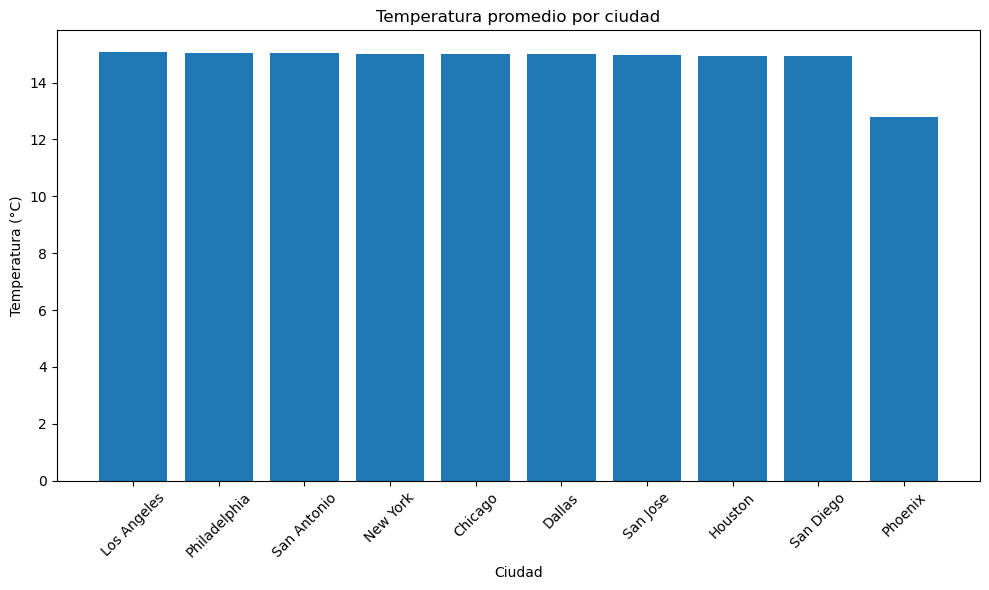

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    graf_temp.index,
    graf_temp.values
)

plt.title("Temperatura promedio por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Temperatura (°C)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Interpretación

El gráfico de barras muestra la temperatura promedio registrada en cada una de las ciudades analizadas. Se observa que **Los Angeles** presenta la temperatura promedio más alta, con aproximadamente **15.08 °C**, mientras que **Phoenix** registra la temperatura promedio más baja (**12.79 °C**). En las demás ciudades las temperaturas promedio son muy similares, alrededor de **15 °C**, lo que indica un comportamiento relativamente homogéneo durante el período de estudio.

## 10.3 Precipitación promedio por ciudad

El siguiente gráfico representa la precipitación promedio registrada en cada ciudad. Esta visualización permite comparar la cantidad media de lluvia y detectar las ciudades con mayores y menores niveles de precipitación.

In [34]:

# Función para calcular la precipitación promedio por ciudad

def precipitacion_promedio_ciudad(df):
    """
    Calcula la precipitación promedio por ciudad.

    Parámetros:
        df (DataFrame): Conjunto de datos.

    Retorna:
        Series: Precipitación promedio por ciudad.
    """

    precipitacion = (
        df.groupby("Location")["Precipitation_mm"]
        .mean()
        .sort_values(ascending=False)
    )

    return precipitacion

In [35]:
graf_prec = precipitacion_promedio_ciudad(datos)

graf_prec

Location
Phoenix         6.087485
Philadelphia    5.008561
San Antonio     5.008091
San Diego       5.006593
Los Angeles     5.004491
Chicago         5.003164
Houston         4.997757
Dallas          4.997508
New York        4.993057
San Jose        4.987398
Name: Precipitation_mm, dtype: float64

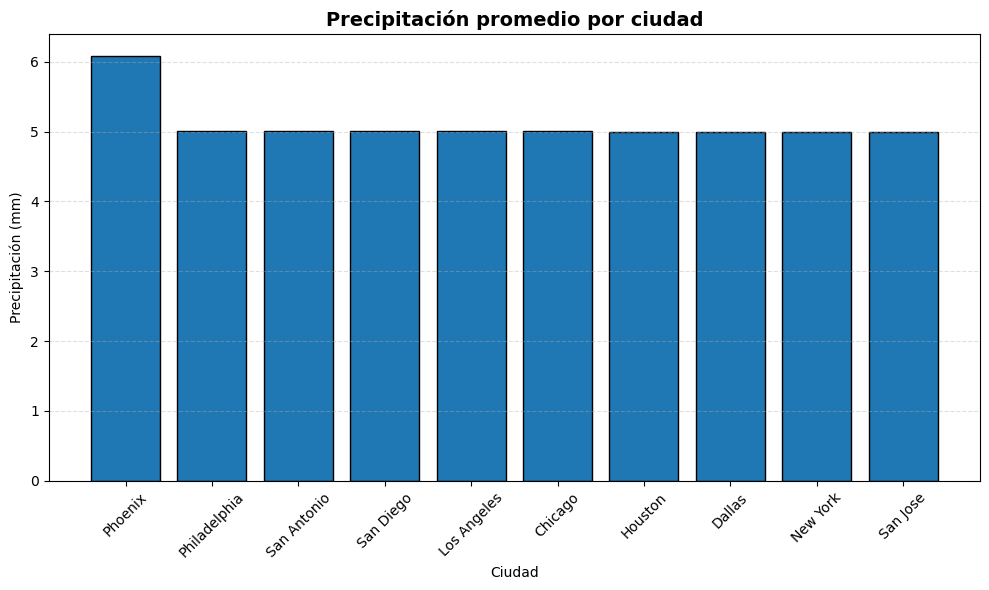

In [36]:
plt.figure(figsize=(10,6))

plt.bar(
    graf_prec.index,
    graf_prec.values,
    edgecolor="black"
)

plt.title("Precipitación promedio por ciudad", fontsize=14, fontweight="bold")
plt.xlabel("Ciudad")
plt.ylabel("Precipitación (mm)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Interpretación

El gráfico de barras muestra la precipitación promedio registrada en cada una de las ciudades analizadas. Se observa que **Phoenix** presenta la mayor precipitación promedio, con aproximadamente **6.09 mm**, mientras que las demás ciudades registran valores cercanos a **5 mm**. En general, la precipitación presenta una variación reducida entre las diferentes ubicaciones, lo que indica un comportamiento relativamente uniforme durante el período de estudio.

## 10.4 Humedad promedio por ciudad

El siguiente gráfico presenta la humedad relativa promedio registrada en cada ciudad. Esta visualización permite comparar las condiciones de humedad entre las diferentes ubicaciones incluidas en el conjunto de datos.

In [37]:

# Función para calcular la humedad promedio por ciudad

def humedad_promedio_ciudad(df):
    """
    Calcula la humedad promedio por ciudad.

    Parámetros:
        df (DataFrame): Conjunto de datos.

    Retorna:
        Series: Humedad promedio por ciudad.
    """

    humedad = (
        df.groupby("Location")["Humidity_pct"]
        .mean()
        .sort_values(ascending=False)
    )

    return humedad

In [38]:
graf_humedad = humedad_promedio_ciudad(datos)

graf_humedad

Location
Chicago         60.088798
Los Angeles     60.072151
San Diego       60.072074
Phoenix         60.048643
Philadelphia    60.044902
New York        60.044688
San Jose        59.986630
Houston         59.967598
Dallas          59.959900
San Antonio     59.932798
Name: Humidity_pct, dtype: float64

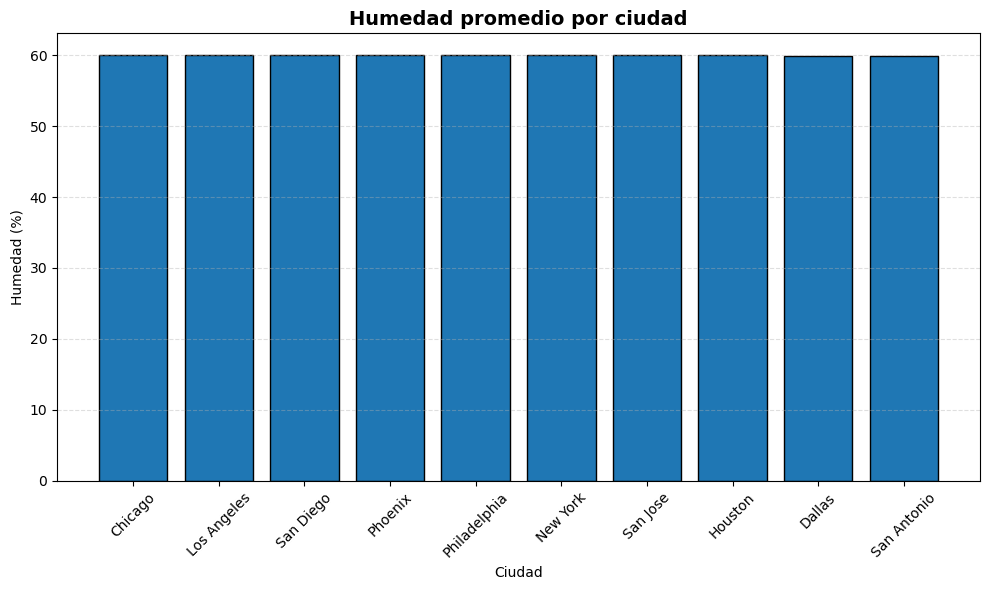

In [39]:
plt.figure(figsize=(10,6))

plt.bar(
    graf_humedad.index,
    graf_humedad.values,
    edgecolor="black"
)

plt.title("Humedad promedio por ciudad", fontsize=14, fontweight="bold")
plt.xlabel("Ciudad")
plt.ylabel("Humedad (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Interpretación

El gráfico de barras muestra la humedad relativa promedio registrada en cada una de las ciudades analizadas. Se observa que los valores de humedad son muy similares, con promedios cercanos al **60 %** en todas las ubicaciones. Las diferencias entre ciudades son mínimas, lo que indica un comportamiento homogéneo de esta variable durante el período de estudio.

## 10.5 Distribución de la temperatura

El siguiente histograma muestra la distribución de los valores de temperatura registrados en el conjunto de datos. Este tipo de gráfico permite observar la frecuencia con la que aparecen determinados rangos de temperatura e identificar la forma general de la distribución.

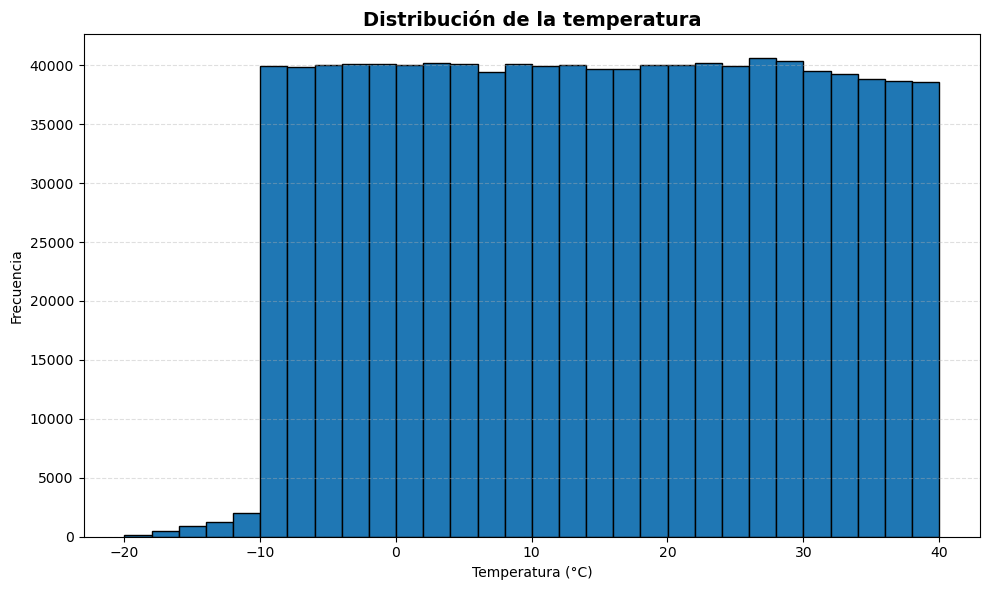

In [40]:
plt.figure(figsize=(10,6))

plt.hist(
    datos["Temperature_C"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribución de la temperatura", fontsize=14, fontweight="bold")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Frecuencia")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Interpretación

El histograma muestra la distribución de las temperaturas registradas en el conjunto de datos. Se observa que los valores se distribuyen de manera relativamente uniforme entre aproximadamente **-10 °C y 40 °C**, sin presentar un único intervalo con una frecuencia claramente predominante. Esto indica que el conjunto de datos incluye una amplia variedad de temperaturas, permitiendo analizar diferentes condiciones climáticas.

In [41]:

# Función para calcular la temperatura promedio por mes

def temperatura_promedio_mes(df):
    """
    Calcula la temperatura promedio por mes.

    Parámetros:
        df (DataFrame): Conjunto de datos.

    Retorna:
        DataFrame: Temperatura promedio por mes.
    """

    temperatura_mes = (
        df.groupby("Mes")["Temperature_C"]
        .mean()
        .reset_index()
    )

    # Orden cronológico de los meses
    orden = ["January", "February", "March", "April", "May"]

    temperatura_mes["Mes"] = pd.Categorical(
        temperatura_mes["Mes"],
        categories=orden,
        ordered=True
    )

    temperatura_mes = temperatura_mes.sort_values("Mes")

    return temperatura_mes

In [42]:
graf_mes = temperatura_promedio_mes(datos)

graf_mes

,Mes,Temperature_C
2,January,14.446461
1,February,14.502081
3,March,15.005691
0,April,15.001603
4,May,15.042793


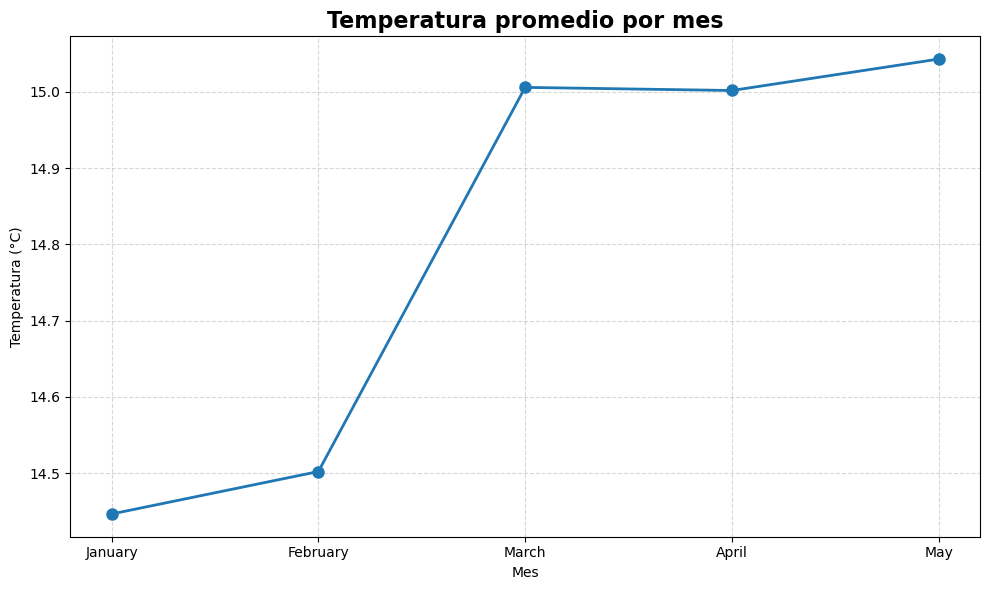

In [43]:
plt.figure(figsize=(10,6))

plt.plot(
    graf_mes["Mes"],
    graf_mes["Temperature_C"],
    marker="o",
    linewidth=2,
    markersize=8
)

plt.title("Temperatura promedio por mes", fontsize=16, fontweight="bold")
plt.xlabel("Mes")
plt.ylabel("Temperatura (°C)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

### Interpretación

El gráfico de líneas muestra la evolución de la temperatura promedio durante los meses analizados. Se observa un incremento gradual desde **enero (14.45 °C)** hasta **marzo (15.01 °C)**, seguido de una ligera estabilidad durante abril y un pequeño aumento en **mayo (15.04 °C)**. En general, la temperatura promedio presenta una tendencia ligeramente creciente a lo largo del período analizado.

## 10.6 Diagrama de caja y bigotes de la temperatura

El siguiente diagrama de caja y bigotes (boxplot) resume la distribución de la temperatura registrada en el conjunto de datos. Este tipo de gráfico permite visualizar la mediana, los cuartiles, la dispersión de los datos y la presencia de posibles valores atípicos.

In [44]:

# Función para generar un diagrama de caja y bigotes

def boxplot_temperatura(df):
    """
    Genera un diagrama de caja y bigotes de la temperatura.

    Parámetros:
        df (DataFrame): Conjunto de datos.

    Retorna:
        None
    """

    plt.figure(figsize=(8,6))

    plt.boxplot(
        df["Temperature_C"],
        vert=True,
        patch_artist=True
    )

    plt.title("Diagrama de caja y bigotes de la temperatura",
              fontsize=14,
              fontweight="bold")

    plt.ylabel("Temperatura (°C)")

    plt.grid(axis="y", linestyle="--", alpha=0.4)

    plt.show()

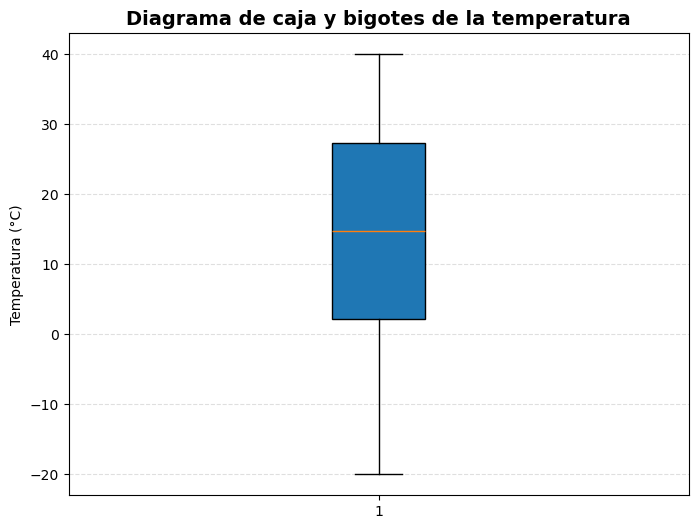

In [45]:
boxplot_temperatura(datos)

### Interpretación

El diagrama de caja y bigotes resume la distribución de la temperatura registrada en el conjunto de datos. La mediana se ubica alrededor de **15 °C**, mientras que el 50 % central de las observaciones se concentra aproximadamente entre **2 °C y 27 °C**. Los valores mínimos y máximos se encuentran cercanos a **-20 °C** y **40 °C**, respectivamente. Además, no se observan valores atípicos fuera de los bigotes, lo que indica que las temperaturas se distribuyen de manera uniforme dentro del rango analizado.

## 10.7 Generación automática de gráficos por ciudad 

Como ejemplo de automatización, se utiliza un bucle para generar y guardar un gráfico de temperatura para cada una de las ciudades presentes en el conjunto de datos. Esta técnica permite automatizar la creación de múltiples visualizaciones, evitando repetir código y facilitando el análisis individual de cada ciudad.

In [46]:
import os

In [47]:

# Función para generar y guardar gráficos por ciudad

def graficos_por_ciudad(df):

    """
    Genera y guarda un gráfico de temperatura para cada ciudad.

    Parámetros:
        df (DataFrame): Conjunto de datos.

    Retorna:
        None
    """

    carpeta = "Graficos_Ciudades"

    # Crear la carpeta si no existe
    os.makedirs(carpeta, exist_ok=True)

    ciudades = df["Location"].unique()

    for ciudad in ciudades:

        datos_ciudad = df[df["Location"] == ciudad]

        plt.figure(figsize=(8,5))

        plt.hist(
            datos_ciudad["Temperature_C"],
            bins=20,
            edgecolor="black"
        )

        plt.title(f"Distribución de temperatura - {ciudad}",
                  fontsize=13,
                  fontweight="bold")

        plt.xlabel("Temperatura (°C)")
        plt.ylabel("Frecuencia")

        plt.grid(axis="y",
                 linestyle="--",
                 alpha=0.4)

        plt.tight_layout()

        nombre = os.path.join(carpeta, f"{ciudad}.png")

        plt.savefig(nombre)

        plt.close()

    print(f"Se generaron {len(ciudades)} gráficos correctamente.")

In [48]:
graficos_por_ciudad(datos)

Se generaron 10 gráficos correctamente.


### Interpretación

Mediante el uso de un bucle `for` fue posible generar automáticamente un gráfico de distribución de temperatura para cada una de las ciudades del conjunto de datos. Esta automatización evita repetir código, facilita el procesamiento de múltiples categorías y demuestra el uso de estructuras de control para optimizar tareas de análisis y visualización de datos.

# 11. Conclusiones

El desarrollo de este proyecto permitió aplicar de manera práctica los conocimientos adquiridos en la asignatura de **Bases de Programación**, utilizando Python para automatizar el análisis de un conjunto de datos climáticos. A lo largo del trabajo fue posible integrar diferentes herramientas y funciones para procesar información de forma organizada y eficiente.

Durante el proceso se realizó la carga, limpieza y manipulación de los datos, verificando que el conjunto de datos no presentara valores nulos ni registros duplicados. Posteriormente, mediante estadísticas descriptivas y análisis exploratorio, fue posible comprender el comportamiento de variables como la temperatura, la humedad, la precipitación y la velocidad del viento en distintas ciudades de Estados Unidos.

Las visualizaciones generadas con **Matplotlib** facilitaron la interpretación de los resultados, permitiendo comparar ciudades, analizar la distribución de las temperaturas e identificar pequeñas variaciones entre los meses. Además, la implementación de funciones y bucles permitió automatizar tareas repetitivas, haciendo que el código fuera más organizado, reutilizable y fácil de mantener.

Este proyecto permitió fortalecer mis habilidades de programación en Python y comprender la importancia del análisis de datos como apoyo para la toma de decisiones. Asimismo, reforzó conceptos fundamentales como el uso de funciones, estructuras de control, manipulación de DataFrames y generación de visualizaciones, conocimientos que serán de gran utilidad en proyectos académicos y profesionales futuros.

# 12. Recomendaciones

Como trabajo futuro, se recomienda ampliar el conjunto de datos incorporando información de un mayor número de ciudades y un período de tiempo más extenso. Esto permitiría realizar análisis más completos y obtener resultados con una mayor representatividad.

También sería recomendable incluir nuevas variables climáticas, como la presión atmosférica, la radiación solar o la calidad del aire, con el fin de realizar estudios más detallados y establecer relaciones entre diferentes factores ambientales.

Desde el punto de vista de la programación, se sugiere continuar fortaleciendo el uso de funciones, módulos y técnicas de automatización para desarrollar códigos más eficientes, reutilizables y fáciles de mantener. Asimismo, podrían incorporarse nuevas visualizaciones o bibliotecas especializadas para enriquecer el análisis de los datos.

Finalmente, se recomienda aplicar la metodología desarrollada en este proyecto a otros conjuntos de datos reales, ya que esto contribuirá a fortalecer las habilidades de programación, análisis de datos y visualización de información, competencias fundamentales para la formación profesional.

# 13. Referencias

McKinney, W. (2022). *Python for Data Analysis: Data Wrangling with Pandas, NumPy, and Jupyter* (3rd ed.). O'Reilly Media.

The Python Software Foundation. (2024). *Python Documentation*. https://docs.python.org/3/

The Pandas Development Team. (2024). *Pandas User Guide*. https://pandas.pydata.org/docs/

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., ... Oliphant, T. E. (2020). *Array programming with NumPy*. Nature, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

The Matplotlib Development Team. (2024). *Matplotlib Documentation*. https://matplotlib.org/stable/

OpenPyXL Developers. (2024). *OpenPyXL Documentation*. https://openpyxl.readthedocs.io/